# Dataset 6

In [102]:
import sys

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor
import seaborn as sns
import os
os.getcwd()

'/scratch.global/gaire004/st_jude/KIDS26-Team18/data/Dataset_06'

In [2]:
# Change the path
os.chdir('/scratch.global/gaire004/st_jude/KIDS26-Team18/data/Dataset_06')

os.getcwd()

'/scratch.global/gaire004/st_jude/KIDS26-Team18/data/Dataset_06'

In [3]:
PROJECT_DIR = Path("/scratch.global/gaire004/st_jude/KIDS26-Team18")

matches = list(PROJECT_DIR.rglob("spatial_plot.py"))

print("Searching under:", PROJECT_DIR)
print("Found:")
for p in matches:
    print(p)

Searching under: /scratch.global/gaire004/st_jude/KIDS26-Team18
Found:
/scratch.global/gaire004/st_jude/KIDS26-Team18/data/spatial_plot.py
/scratch.global/gaire004/st_jude/KIDS26-Team18/src/spatial_plot.py


In [4]:
RAW_DIR = Path(
    "/scratch.global/gaire004/st_jude/KIDS26-Team18/data/Dataset_06/processed_data/gaire004"
)

SDATA_PATH = RAW_DIR / "sdata.zarr"

assert SDATA_PATH.is_dir(), f"Missing zarr store: {SDATA_PATH}"

print(f"Zarr path: {SDATA_PATH}")

Zarr path: /scratch.global/gaire004/st_jude/KIDS26-Team18/data/Dataset_06/processed_data/gaire004/sdata.zarr


In [5]:
sdata = sd.read_zarr(SDATA_PATH)
adata = sdata["table"]

print("Tables:", list(sdata.tables.keys()))
print("Shapes:", list(sdata.shapes.keys()))
print("Points:", list(sdata.points.keys()))
print("Images:", list(sdata.images.keys()) or "(none)")
print(f"\nAnnData: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f"obs columns ({len(adata.obs.columns)}): {list(adata.obs.columns)[:12]} ...")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"layers: {list(adata.layers.keys()) or '(none)'}")
print(f"Table region: {adata.uns['spatialdata_attrs']['region']}")

Tables: ['table']
Shapes: ['cell_boundaries']
Points: ['transcripts']
Images: (none)

AnnData: 71,138 cells x 6,537 genes
obs columns (134): ['RNA_Dermis_RNA_pipeline_Cell.Typing.InSituType.2_1_clusters', 'RNA_Dermis_RNA_pipeline_Cell.Typing.InSituType.2_1_posterior_probability', 'RNA_Dermis_RNA_pipeline_Cell.Typing.InSituType.1_1_clusters', 'RNA_Dermis_RNA_pipeline_Cell.Typing.InSituType.1_1_posterior_probability', 'RNA_Derma_Skin_RNA_sup_semisup_Cell.Typing.InSituType.2_1_clusters', 'RNA_Derma_Skin_RNA_sup_semisup_Cell.Typing.InSituType.2_1_posterior_probability', 'RNA_Derma_Skin_RNA_sup_semisup_Cell.Typing.InSituType.1_1_clusters', 'RNA_Derma_Skin_RNA_sup_semisup_Cell.Typing.InSituType.1_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'CenterX_local_px'] ...
obsm keys: ['spatial', 'global']
layers: (none)
Table region: cell_boundaries


In [6]:
# Sanity check: .X should hold integer raw RNA counts
x = adata.X
vals = x.data if hasattr(x, "data") else np.asarray(x).ravel()

assert vals.min() >= 0, f"Expected nonnegative counts, got min={vals.min()}"
assert np.allclose(vals, np.round(vals)), "Non-integer values in .X"

# exprMat includes Negative/SystemControl probes; compare RNA genes only to nCount_RNA
rna_mask = ~adata.var_names.str.match(r"^(Negative|SystemControl)")
row_sums = np.asarray(adata[:, rna_mask].X.sum(axis=1)).ravel()
ref = adata.obs["nCount_RNA"].to_numpy(dtype=float)
assert np.allclose(row_sums, ref, atol=5), "X row sums (RNA genes) must match obs['nCount_RNA']"

print(f"X holds integer counts (min={vals.min():.0f}, max={vals.max():.0f})")
print(f"Row-sum check vs nCount_RNA (RNA genes, atol=5): OK ({adata.n_obs:,} cells)")

X holds integer counts (min=1, max=699)
Row-sum check vs nCount_RNA (RNA genes, atol=5): OK (71,138 cells)


In [7]:
SCANPY_CFG = {
    "n_pcs": 30,
    "n_neighbors": 15,
    "leiden_resolution": 0.6,
    "rank_genes_top_n": 20,
    "seed": 42,
}

adata_sc = adata.copy()

# use all genes (no HVG subset)
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
sc.pp.scale(adata_sc, max_value=10)


n_comps = min(SCANPY_CFG["n_pcs"], adata_sc.n_obs - 1, adata_sc.n_vars - 1)
sc.tl.pca(adata_sc, n_comps=n_comps, random_state=SCANPY_CFG["seed"])
sc.pp.neighbors(adata_sc, n_neighbors=SCANPY_CFG["n_neighbors"])
sc.tl.leiden(
    adata_sc,
    resolution=SCANPY_CFG["leiden_resolution"],
    key_added="leiden",
    random_state=SCANPY_CFG["seed"],
)
sc.tl.umap(adata_sc, random_state=SCANPY_CFG["seed"])

# Copy results back to adata (single object used throughout)
adata.obs["leiden"] = adata_sc.obs["leiden"].astype(str)
adata.obsm["X_umap"] = adata_sc.obsm["X_umap"]

/projects/standard/shens/gaire004/biohack-spatial/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_2639832/2178374937.py:20: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


# Rule Based Approach

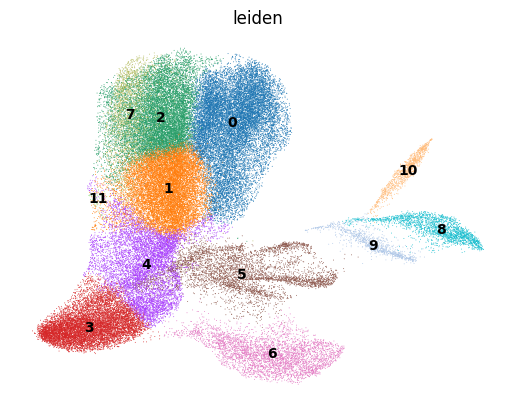

In [8]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    frameon=False,
)

In [9]:
print("adata shape:", adata.shape)

print("Number of Leiden clusters:",
      adata.obs["leiden"].nunique())

print("Leiden clusters:")
print(adata.obs["leiden"].value_counts().sort_index())

adata shape: (71138, 6537)
Number of Leiden clusters: 12
Leiden clusters:
leiden
0     15478
1     12588
2     11066
3      9497
4      7737
5      4506
6      3855
7      2307
8      2054
9       999
10      994
11       57
Name: count, dtype: int64


In [10]:
adata_sc = adata.copy()
# use all genes (no HVG subset)
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
sc.tl.rank_genes_groups(adata_sc, groupby="leiden", method="wilcoxon", use_raw=False)
adata.uns["rank_genes_groups"] = adata_sc.uns["rank_genes_groups"]

In [13]:
sc.tl.dendrogram(
    adata,
    groupby="leiden",
    use_rep="X_pca",
)

,cluster,names,scores,logfoldchanges,pvals,pvals_adj
0,0,PERP,141.163376,4.652334,0.000000e+00,0.000000e+00
1,0,KRT6A,139.132111,5.333189,0.000000e+00,0.000000e+00
2,0,S100A8,138.527542,6.098644,0.000000e+00,0.000000e+00
3,0,S100A9,136.708069,5.883671,0.000000e+00,0.000000e+00
4,0,KRT1,131.512970,5.508445,0.000000e+00,0.000000e+00
5,1,NDUFA3,64.200279,2.154014,0.000000e+00,0.000000e+00
6,1,SNRPD1,61.813053,2.048617,0.000000e+00,0.000000e+00
7,1,COX1,59.948555,1.728778,0.000000e+00,0.000000e+00
8,1,COX2,59.444012,1.645271,0.000000e+00,0.000000e+00
9,1,SIGMAR1,52.275806,1.403515,0.000000e+00,0.000000e+00


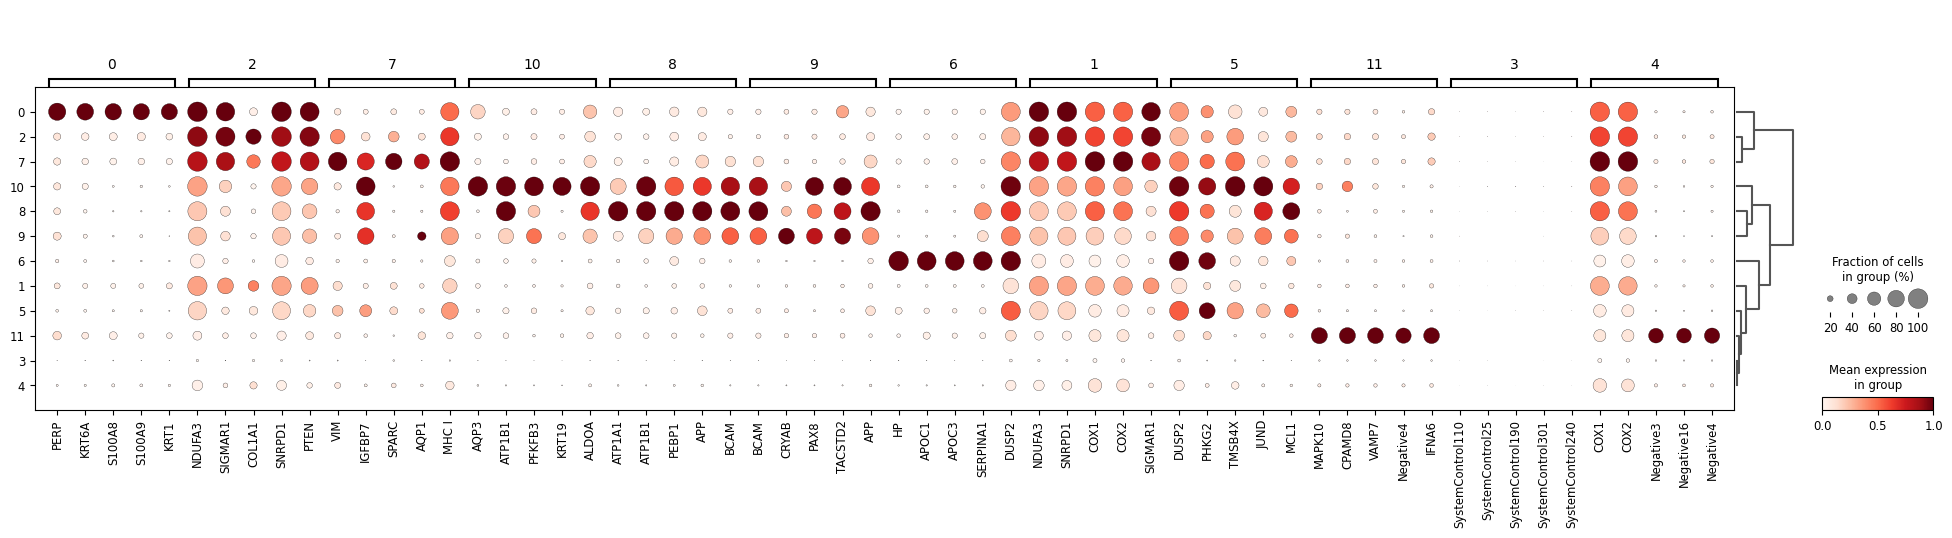

In [14]:
#top_n = SCANPY_CFG["rank_genes_top_n"]
top_n = 5
clusters = sorted(adata.obs["leiden"].unique(), key=lambda x: int(x))

marker_tables = []
for cluster in clusters:
    df = sc.get.rank_genes_groups_df(adata, group=cluster)
    df = df.head(top_n).copy()
    df.insert(0, "cluster", cluster)
    marker_tables.append(df)

markers_top20 = pd.concat(marker_tables, ignore_index=True)
display(markers_top20)

sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=top_n,
    groupby="leiden",
    standard_scale="var",
    show=False,
)
plt.show()

In [15]:
marker_dict = (
    markers_top20
    .groupby("cluster", sort=False)["names"]
    .apply(list)
    .to_dict()
)

marker_dict

{'0': ['PERP', 'KRT6A', 'S100A8', 'S100A9', 'KRT1'],
 '1': ['NDUFA3', 'SNRPD1', 'COX1', 'COX2', 'SIGMAR1'],
 '2': ['NDUFA3', 'SIGMAR1', 'COL1A1', 'SNRPD1', 'PTEN'],
 '3': ['SystemControl110',
  'SystemControl25',
  'SystemControl190',
  'SystemControl301',
  'SystemControl240'],
 '4': ['COX1', 'COX2', 'Negative3', 'Negative16', 'Negative4'],
 '5': ['DUSP2', 'PHKG2', 'TMSB4X', 'JUND', 'MCL1'],
 '6': ['HP', 'APOC1', 'APOC3', 'SERPINA1', 'DUSP2'],
 '7': ['VIM', 'IGFBP7', 'SPARC', 'AQP1', 'MHC I'],
 '8': ['ATP1A1', 'ATP1B1', 'PEBP1', 'APP', 'BCAM'],
 '9': ['BCAM', 'CRYAB', 'PAX8', 'TACSTD2', 'APP'],
 '10': ['AQP3', 'ATP1B1', 'PFKFB3', 'KRT19', 'ALDOA'],
 '11': ['MAPK10', 'CPAMD8', 'VAMP7', 'Negative4', 'IFNA6']}

In [16]:
control_mask = (
    adata.var_names.str.match(r"^(Negative|SystemControl)")
    | adata.var_names.str.endswith("-circ")
)

# per-cell background stats, computed on the FULL adata (with controls)
adata.obs["neg_mean"] = np.asarray(adata[:, adata.var_names.str.startswith("Negative")].X.mean(axis=1)).ravel()
adata.obs["neg_frac"] = np.asarray(adata[:, control_mask].X.sum(axis=1)).ravel() / (adata.obs["nCount_RNA"] + 1e-9)


In [17]:
print("Negative/SystemControl probes:", adata.var_names.str.match(r"^(Negative|SystemControl)").sum())
print("-circ probes:", adata.var_names.str.endswith("-circ").sum())
print("Total excluded:", control_mask.sum(), "/", adata.n_vars)

Negative/SystemControl probes: 344
-circ probes: 10
Total excluded: 354 / 6537


In [19]:
adata_sc = adata[:, ~control_mask].copy()

sc.pp.normalize_total(adata_sc, target_sum=1e4)   # now sums only real genes — more correct too,
sc.pp.log1p(adata_sc)                             # since control probes shouldn't inflate library size
sc.pp.scale(adata_sc, max_value=10)

n_comps = min(SCANPY_CFG["n_pcs"], adata_sc.n_obs - 1, adata_sc.n_vars - 1)
sc.tl.pca(adata_sc, n_comps=n_comps, random_state=SCANPY_CFG["seed"])
sc.pp.neighbors(adata_sc, n_neighbors=SCANPY_CFG["n_neighbors"])
sc.tl.leiden(adata_sc, resolution=SCANPY_CFG["leiden_resolution"], key_added="leiden", random_state=SCANPY_CFG["seed"])
sc.tl.umap(adata_sc, random_state=SCANPY_CFG["seed"])

/projects/standard/shens/gaire004/biohack-spatial/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [20]:
adata.obs["leiden"] = adata_sc.obs["leiden"].astype(str).astype("category")
adata.obsm["X_umap"] = adata_sc.obsm["X_umap"]
adata.obsm["X_pca"] = adata_sc.obsm["X_pca"]   

In [21]:
adata_sc = adata[:, ~control_mask].copy()
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
adata_sc.obs["leiden"] = adata.obs["leiden"].values   # carry over the labels you just computed

sc.tl.rank_genes_groups(adata_sc, groupby="leiden", method="wilcoxon", use_raw=False)
adata.uns["rank_genes_groups"] = adata_sc.uns["rank_genes_groups"]

In [22]:
sc.tl.dendrogram(adata, groupby="leiden", use_rep="X_pca")

marker_tables = []
for cluster in sorted(adata.obs["leiden"].unique(), key=int):
    df = sc.get.rank_genes_groups_df(adata, group=cluster).head(20).copy()
    df.insert(0, "cluster", cluster)
    marker_tables.append(df)
markers_top20 = pd.concat(marker_tables, ignore_index=True)
marker_dict = markers_top20.groupby("cluster", sort=False)["names"].apply(list).to_dict()

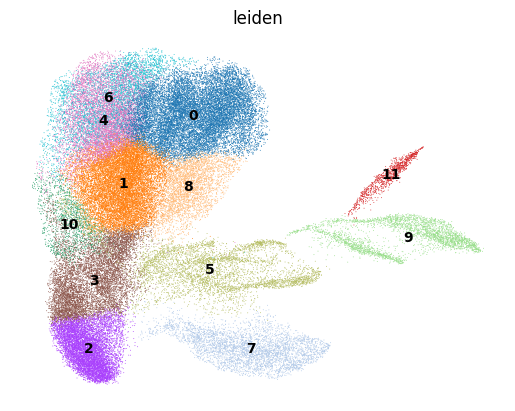

In [23]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    frameon=False,
)

,cluster,names,scores,logfoldchanges,pvals,pvals_adj
0,0,SNRPD1,118.786415,2.807313,0.0,0.0
1,0,NDUFA3,118.164345,2.857217,0.0,0.0
2,0,PERP,110.629486,3.557366,0.0,0.0
3,0,VPS29,108.238731,2.620477,0.0,0.0
4,0,KRT1,105.765556,4.231554,0.0,0.0
...,...,...,...,...,...,...
235,11,TMSB4X,43.613415,3.889735,0.0,0.0
236,11,MUC1,43.277813,5.329592,0.0,0.0
237,11,ENO1,42.783703,4.204398,0.0,0.0
238,11,ATP5F1B,42.490047,4.262949,0.0,0.0


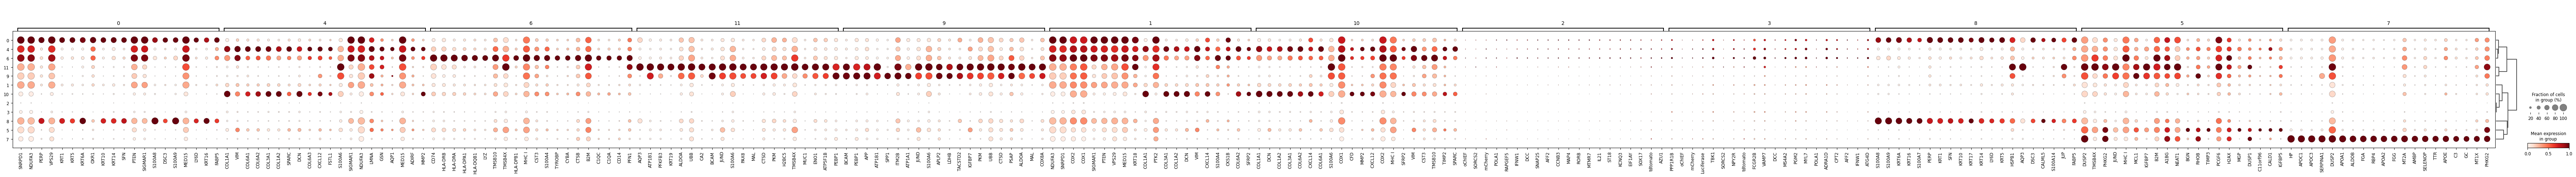

In [24]:
#top_n = SCANPY_CFG["rank_genes_top_n"]
top_n = 20
clusters = sorted(adata.obs["leiden"].unique(), key=lambda x: int(x))

marker_tables = []
for cluster in clusters:
    df = sc.get.rank_genes_groups_df(adata, group=cluster)
    df = df.head(top_n).copy()
    df.insert(0, "cluster", cluster)
    marker_tables.append(df)

markers_top20 = pd.concat(marker_tables, ignore_index=True)
display(markers_top20)

sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=top_n,
    groupby="leiden",
    standard_scale="var",
    show=False,
)
plt.show()

In [25]:
marker_dict = (
    markers_top20
    .groupby("cluster", sort=False)["names"]
    .apply(list)
    .to_dict()
)

marker_dict

{'0': ['SNRPD1',
  'NDUFA3',
  'PERP',
  'VPS29',
  'KRT1',
  'KRT5',
  'KRT6A',
  'OXR1',
  'KRT10',
  'KRT14',
  'SFN',
  'PTEN',
  'SIGMAR1',
  'S100A8',
  'DSC3',
  'S100A9',
  'MED15',
  'LY6D',
  'KRT16',
  'FABP5'],
 '1': ['NDUFA3',
  'SNRPD1',
  'COX2',
  'COX1',
  'SIGMAR1',
  'PTEN',
  'VPS29',
  'MED15',
  'KRT18',
  'COL1A1',
  'PTK2',
  'COL3A1',
  'COL1A2',
  'DCN',
  'VIM',
  'CXCL14',
  'S100A4',
  'CKS1B',
  'COL6A2',
  'SFRP2'],
 '2': ['oChIEF',
  'SORCS2',
  'mCherry',
  'POLA1',
  'RAPGEF5',
  'IFNW1',
  'DCC',
  'SNAP25',
  'AFF2',
  'CCNB3',
  'MAP4',
  'RORB',
  'MTMR7',
  'IL21',
  'ST18',
  'KCNQ3',
  'EIF1AY',
  'SOX17',
  'tdtomato',
  'AZU1'],
 '3': ['PPP1R1B',
  'oChIEF',
  'mCherry',
  'Luciferase',
  'TBK1',
  'SORCS2',
  'NPY2R',
  'tdtomato',
  'FCGR2B',
  'VAMP7',
  'DCC',
  'MS4A2',
  'PGM2',
  'MYL7',
  'POLA1',
  'ADRA1D',
  'CPT2',
  'AFF2',
  'IFNW1',
  'ATG4D'],
 '4': ['COL1A1',
  'VIM',
  'COL6A1',
  'COL6A2',
  'COL3A1',
  'COL1A2',
  'SPARC',


In [26]:
# Based on the top-10 marker lists (Leiden, control-probe-excluded)
# Keys are Leiden cluster IDs (strings). Unmapped clusters become "Unassigned".
CLUSTER_ANNOTATIONS = {
    "0":  "Inflamed_keratinocyte",
    "1":  "Fibroblast",
    "2":  "Unclear",
    "3":  "Unclear",
    "4":  "Fibroblast",
    "5":  "Myofibroblast/Perivascular",
    "6":  "Macrophage",
    "7":  "Unclear",
    "8":  "Inflamed_keratinocyte",
    "9":  "Unclear",
    "10": "Fibroblast",
    "11": "Unclear",
}

adata.obs["cell_type_scanpy"] = (
    adata.obs["leiden"]
    .astype(str)
    .map(CLUSTER_ANNOTATIONS)
    .fillna("Unassigned")
)

adata.obs["cell_type_scanpy"] = adata.obs["cell_type_scanpy"].astype("category")

display(
    adata.obs["cell_type_scanpy"].value_counts(dropna=False)
)

cell_type_scanpy
Unclear                       23735
Fibroblast                    20282
Inflamed_keratinocyte         18412
Myofibroblast/Perivascular     4795
Macrophage                     3914
Name: count, dtype: int64

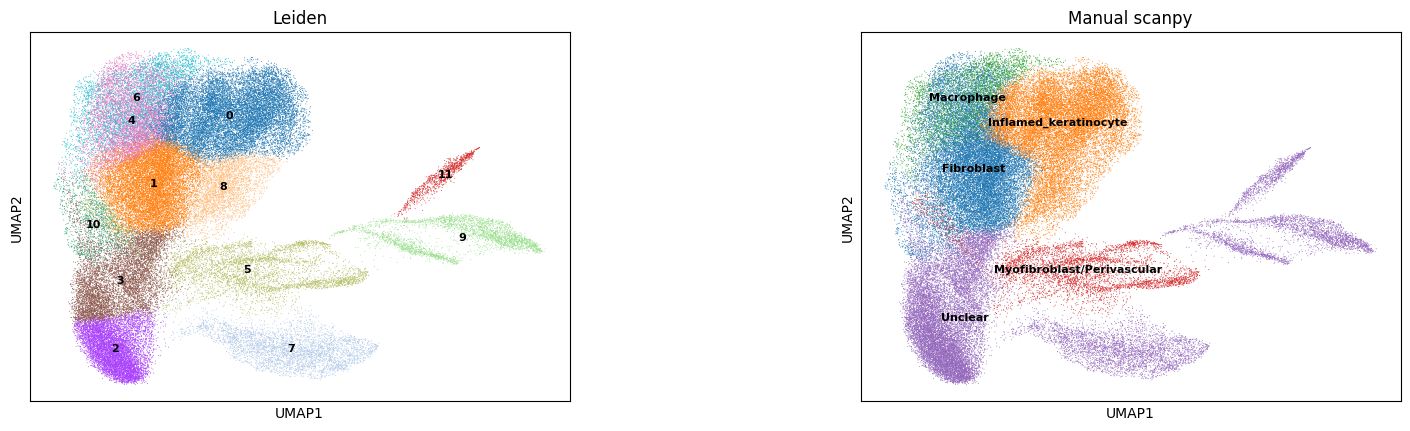

In [27]:
sc.pl.umap(
    adata,
    color=["leiden", "cell_type_scanpy"],
    wspace=0.4,
    title=["Leiden", "Manual scanpy"],
    legend_loc="on data",
    legend_fontsize=8,
)

In [28]:
PROJECT_DIR = Path("/scratch.global/gaire004/st_jude/KIDS26-Team18")
sys.path.insert(0, str(PROJECT_DIR / "src"))
from plot import SpatialCoord_plot

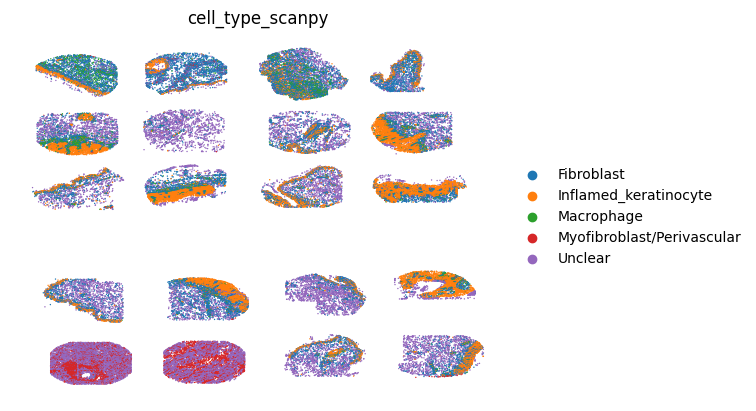

In [29]:
SpatialCoord_plot(
    adata,
    variable="cell_type_scanpy",
    x_col="CenterX_global_px",
    y_col="CenterY_global_px",
    size=4,
)

# Rule based 

In [32]:
FIBRO_CANDIDATES = [
    "COL1A1",
    "COL1A2",
    "DCN",
    "COL3A1"
]

INFLAMED_KERA_CANDIDATES = [
    "S100A8",
    "S100A9",
    "KRT6A",
    "KRT16"
]

MYOFIBRO_PERIVASCULAR_CANDIDATES = [
    "ACTA2",
    "TAGLN",
    "MCAM",
    "CSPG4"
]

MACROPHAGE_CANDIDATES = [
    "LYZ",
    "TYROBP",
    "C1QA",
    "CD14"
]

In [33]:
def detection_rate(adata, genes):
    """Fraction of cells with raw count > 0 for each gene in adata."""
    
    # Only use genes that are actually present in the AnnData object
    present = [g for g in genes if g in adata.var_names]

    rates = {}

    for gene in present:
        x = adata[:, gene].X

        # Handle sparse matrices
        if hasattr(x, "toarray"):
            x = x.toarray().ravel()
        else:
            x = np.asarray(x).ravel()

        # Fraction of cells with count > 0
        rates[gene] = float((x > 0).mean())

    return pd.Series(rates).sort_values(ascending=False)


# Calculate detection rates
fibro_rates = detection_rate(adata, FIBRO_CANDIDATES)
kera_rates = detection_rate(adata, INFLAMED_KERA_CANDIDATES)
myofibro_rates = detection_rate(adata, MYOFIBRO_PERIVASCULAR_CANDIDATES)
macrophage_rates = detection_rate(adata, MACROPHAGE_CANDIDATES)


# Select the top 4 detected markers from each candidate group
FIBRO_MARKERS = fibro_rates.head(4).index.tolist()
KERA_MARKERS = kera_rates.head(4).index.tolist()
MYOFIBRO_MARKERS = myofibro_rates.head(4).index.tolist()
MACROPHAGE_MARKERS = macrophage_rates.head(4).index.tolist()


# Display results
print("Selected Fibroblast markers:")
display(fibro_rates.head(4))

print("\nSelected Inflamed Keratinocyte markers:")
display(kera_rates.head(4))

print("\nSelected Myofibroblast / Perivascular markers:")
display(myofibro_rates.head(4))

print("\nSelected Macrophage markers:")
display(macrophage_rates.head(4))


# Print marker lists
print(f"\nFIBRO_MARKERS      = {FIBRO_MARKERS}")
print(f"KERA_MARKERS       = {KERA_MARKERS}")
print(f"MYOFIBRO_MARKERS   = {MYOFIBRO_MARKERS}")
print(f"MACROPHAGE_MARKERS = {MACROPHAGE_MARKERS}")

Selected Fibroblast markers:


COL1A1    0.346720
DCN       0.290674
COL3A1    0.256769
COL1A2    0.235528
dtype: float64


Selected Inflamed Keratinocyte markers:


KRT6A     0.282015
S100A8    0.276631
S100A9    0.273300
KRT16     0.226096
dtype: float64


Selected Myofibroblast / Perivascular markers:


CSPG4    0.199345
ACTA2    0.175912
TAGLN    0.159872
MCAM     0.077750
dtype: float64


Selected Macrophage markers:


CD14      0.165369
LYZ       0.155725
C1QA      0.142638
TYROBP    0.142231
dtype: float64


FIBRO_MARKERS      = ['COL1A1', 'DCN', 'COL3A1', 'COL1A2']
KERA_MARKERS       = ['KRT6A', 'S100A8', 'S100A9', 'KRT16']
MYOFIBRO_MARKERS   = ['CSPG4', 'ACTA2', 'TAGLN', 'MCAM']
MACROPHAGE_MARKERS = ['CD14', 'LYZ', 'C1QA', 'TYROBP']


In [48]:
def _get_gene_counts(adata, genes):
    """Return (n_cells, n_genes) array of transcript counts from .X."""
    
    # Keep only genes that are present in the dataset
    genes_present = [g for g in genes if g in adata.var_names]

    if len(genes_present) == 0:
        return np.empty((adata.n_obs, 0))

    x = adata[:, genes_present].X

    if hasattr(x, "toarray"):
        return x.toarray()

    return np.asarray(x)


def assign_rule_labels(adata, marker_sets):
    """Assign labels when all genes in a cell type's panel have count > 0.

    marker_sets: dict mapping cell type name -> list of marker genes.
    """

    pos_masks = {}

    for cell_type, genes in marker_sets.items():

        # Only use markers present in the dataset
        genes_present = [g for g in genes if g in adata.var_names]

        if len(genes_present) == 0:
            # No markers available for this cell type
            pos_masks[cell_type] = np.zeros(adata.n_obs, dtype=bool)
            continue

        x = _get_gene_counts(adata, genes_present)

        # Cell is positive only if ALL markers have count > 0
        pos_masks[cell_type] = (x > 0).all(axis=1)

    # Number of cell-type panels positive in each cell
    n_pos = np.sum(list(pos_masks.values()), axis=0)

    # Default label
    labels = np.full(
        adata.n_obs,
        "Unassigned",
        dtype=object
    )

    # Cells positive for more than one cell type
    labels[n_pos > 1] = "Ambiguous"

    # Cells positive for exactly one cell type
    for cell_type, pos in pos_masks.items():
        labels[pos & (n_pos == 1)] = cell_type

    return labels


# Marker sets based on the candidate groups defined above
MARKER_SETS = {
    "Inflamed_keratinocyte": KERA_MARKERS,
    "Fibroblast": FIBRO_MARKERS,
    "Myofibroblast/Perivascular": MYOFIBRO_MARKERS,
    "Macrophage": MACROPHAGE_MARKERS,
}


# Assign rule-based cell-type labels
adata.obs["cell_type_rule"] = pd.Categorical(
    assign_rule_labels(adata, MARKER_SETS)
)


# Display results
print("Rule-based labels")
display(
    adata.obs["cell_type_rule"].value_counts()
)

Rule-based labels


cell_type_rule
Unassigned                    53549
Inflamed_keratinocyte          9402
Fibroblast                     6511
Ambiguous                       760
Macrophage                      614
Myofibroblast/Perivascular      302
Name: count, dtype: int64

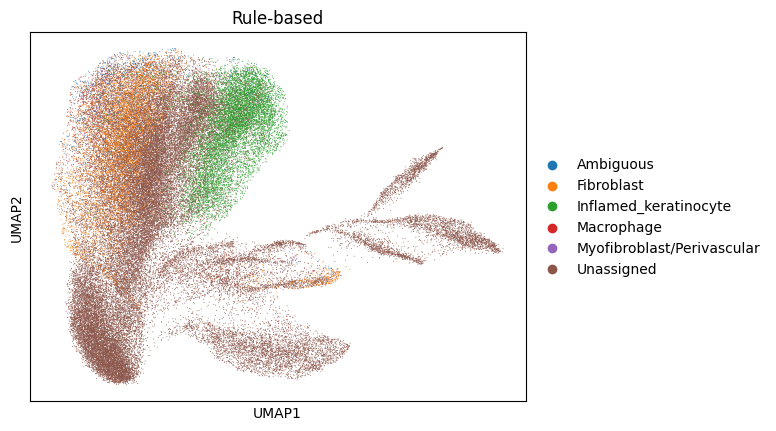

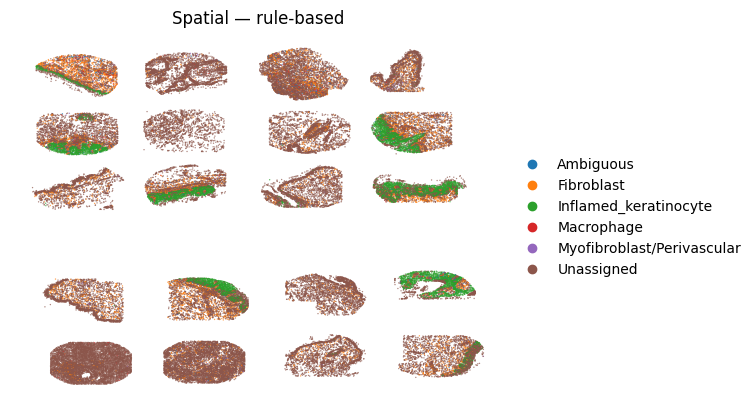

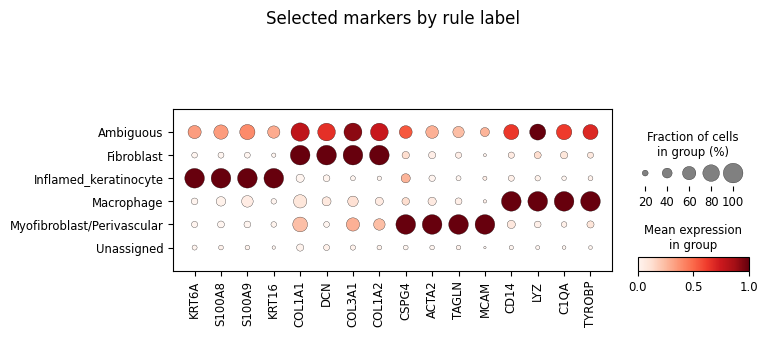

In [49]:
# UMAP — rule-based labels
sc.pl.umap(
    adata,
    color="cell_type_rule",
    title="Rule-based",
)


# Spatial plot — rule-based labels
SpatialCoord_plot(
    adata,
    variable="cell_type_rule",
    x_col="CenterX_global_px",
    y_col="CenterY_global_px",
    size=4,
    alpha=0.7,
    title="Spatial — rule-based",
)

# Marker expression by rule-based label
sc.pl.dotplot(
    adata,
    var_names=KERA_MARKERS + FIBRO_MARKERS + MYOFIBRO_MARKERS + MACROPHAGE_MARKERS,
    groupby="cell_type_rule",
    standard_scale="var",
    title="Selected markers by rule label",
)

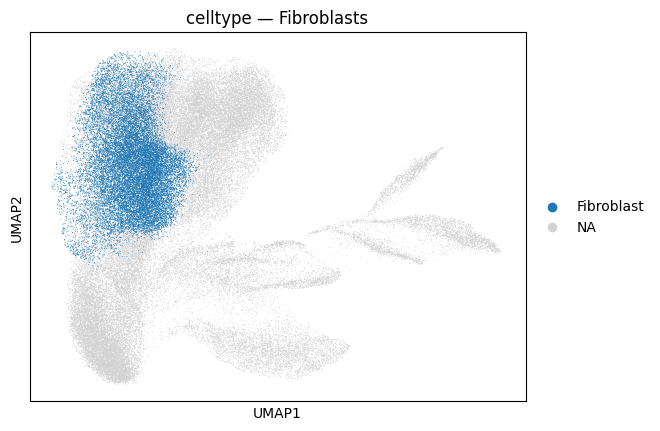

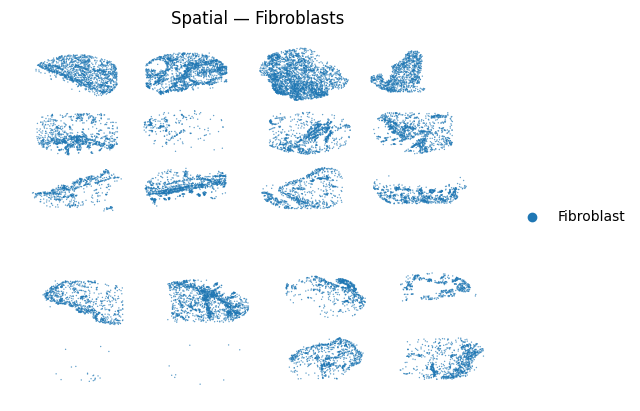

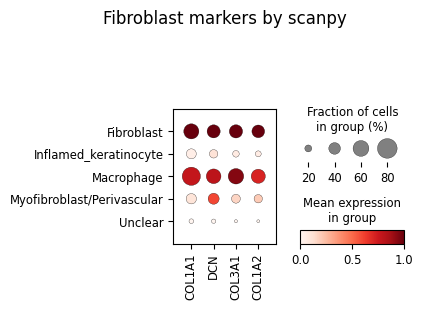

In [50]:
# Subset to cells the rule-based method called Fibroblasts
fibro_adata_scanpy = adata[adata.obs["cell_type_scanpy"] == "Fibroblast"].copy()
fibro_adata_rulebased = adata[adata.obs["cell_type_rule"] == "Fibroblast"].copy()

# UMAP — Fibroblasts highlighted against the full population
sc.pl.umap(
    adata,
    color="cell_type_scanpy",
    groups=["Fibroblast"],
    title="celltype — Fibroblasts",
)


# Spatial plot — Fibroblasts only
SpatialCoord_plot(
    fibro_adata_scanpy,
    variable="cell_type_scanpy",
    x_col="CenterX_global_px",
    y_col="CenterY_global_px",
    size=4,
    alpha=0.7,
    title="Spatial — Fibroblasts",
)

# Marker expression — fibroblast markers only, across all rule-based labels
sc.pl.dotplot(
    adata,
    var_names=FIBRO_MARKERS,
    groupby="cell_type_scanpy",
    standard_scale="var",
    title="Fibroblast markers by scanpy",
)

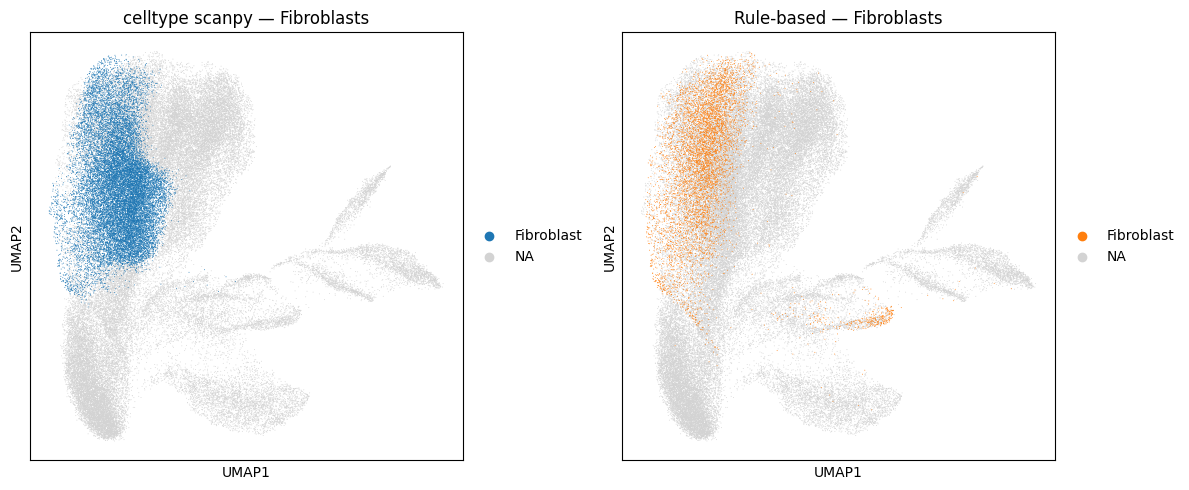

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc.pl.umap(
    adata,
    color="cell_type_scanpy",
    groups=["Fibroblast"],
    title="celltype scanpy — Fibroblasts",
    ax=axes[0],
    show=False,
)

sc.pl.umap(
    adata,
    color="cell_type_rule",
    groups=["Fibroblast"],
    title="Rule-based — Fibroblasts",
    ax=axes[1],
    show=False,
)

plt.tight_layout()
plt.show()

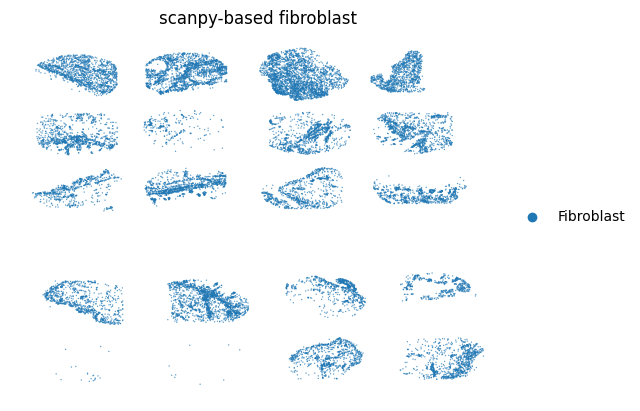

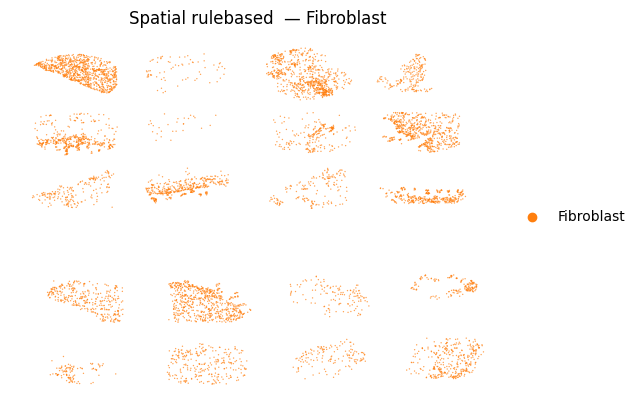

In [52]:
SpatialCoord_plot(
    fibro_adata_scanpy,
    variable="cell_type_scanpy",
    x_col="CenterX_global_px",
    y_col="CenterY_global_px",
    size=4,
    alpha=0.7,
    title="scanpy-based fibroblast",
)

# Spatial plot — Fibroblasts only
SpatialCoord_plot(
    fibro_adata_rulebased,
    variable="cell_type_rule",
    x_col="CenterX_global_px",
    y_col="CenterY_global_px",
    size=4,
    alpha=0.7,
    title="Spatial rulebased  — Fibroblast",
)

In [53]:
print(f"Comparison for sample:\n")

print("=== Counts ===")
summary = pd.DataFrame({
    "cell_type_scanpy": adata.obs["cell_type_scanpy"].value_counts(),
    "cell_type_rule": adata.obs["cell_type_rule"].value_counts(),
})
display(summary)

print("\n=== Crosstab (scanpy rows × rule cols) ===")
ct = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule"],
    margins=True,
)
display(ct)

print("\n=== Row-normalized crosstab ===")
ct_norm = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule"],
    normalize="index",
).round(3)
display(ct_norm)

Comparison for sample:

=== Counts ===


,cell_type_scanpy,cell_type_rule
Ambiguous,NaN,760.0
Fibroblast,20282.0,6511.0
Inflamed_keratinocyte,18412.0,9402.0
Macrophage,3914.0,614.0
Myofibroblast/Perivascular,4795.0,302.0
Unassigned,NaN,53549.0
Unclear,23735.0,NaN



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned,All
cell_type_scanpy,,,,,,,
Fibroblast,204,4926,240,81,228,14603,20282
Inflamed_keratinocyte,139,250,8974,16,27,9006,18412
Macrophage,401,782,171,473,16,2071,3914
Myofibroblast/Perivascular,16,365,7,28,31,4348,4795
Unclear,0,188,10,16,0,23521,23735
All,760,6511,9402,614,302,53549,71138



=== Row-normalized crosstab ===


cell_type_rule,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.010,0.243,0.012,0.004,0.011,0.720
Inflamed_keratinocyte,0.008,0.014,0.487,0.001,0.001,0.489
Macrophage,0.102,0.200,0.044,0.121,0.004,0.529
Myofibroblast/Perivascular,0.003,0.076,0.001,0.006,0.006,0.907
Unclear,0.000,0.008,0.000,0.001,0.000,0.991


In [55]:
PROJECT_DIR = Path("/scratch.global/gaire004/st_jude/KIDS26-Team18")
sys.path.insert(0, str(PROJECT_DIR / "src"))
from plot import SpatialCoord_plot, custom_barplot

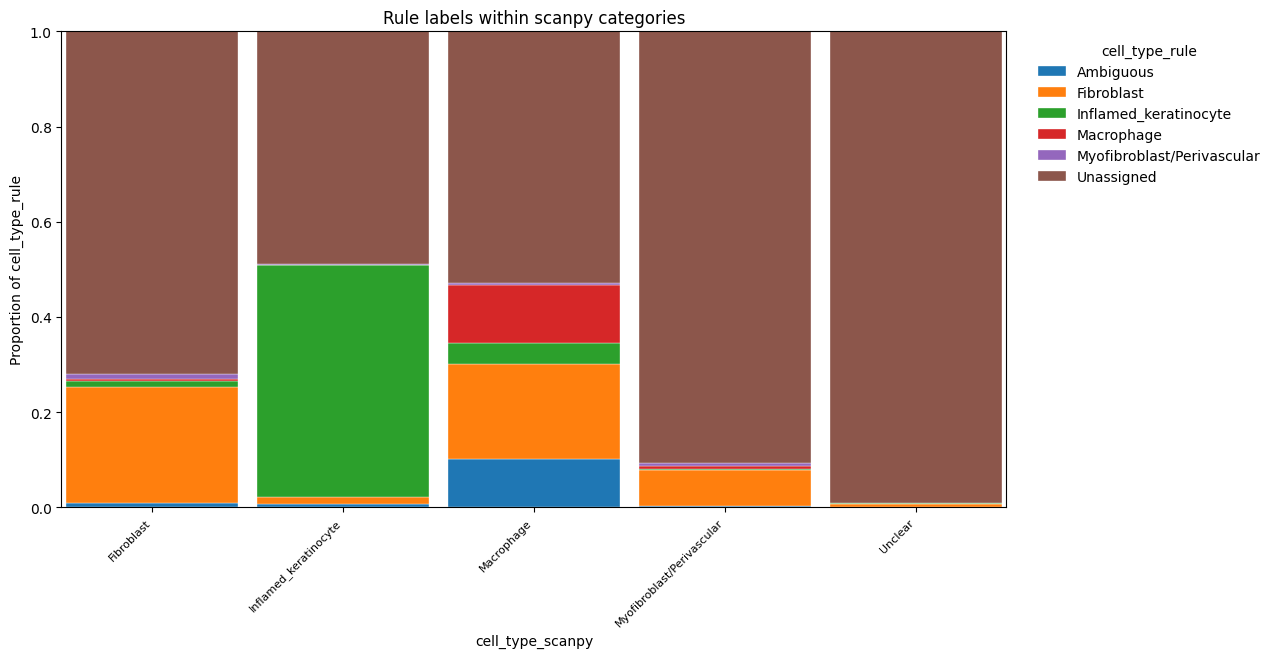

(cell_type_rule              Ambiguous  Fibroblast  Inflamed_keratinocyte  \
 cell_type_scanpy                                                           
 Fibroblast                   0.010058    0.242875               0.011833   
 Inflamed_keratinocyte        0.007549    0.013578               0.487400   
 Macrophage                   0.102453    0.199796               0.043689   
 Myofibroblast/Perivascular   0.003337    0.076121               0.001460   
 Unclear                      0.000000    0.007921               0.000421   
 
 cell_type_rule              Macrophage  Myofibroblast/Perivascular  Unassigned  
 cell_type_scanpy                                                                
 Fibroblast                    0.003994                    0.011241    0.719998  
 Inflamed_keratinocyte         0.000869                    0.001466    0.489138  
 Macrophage                    0.120848                    0.004088    0.529126  
 Myofibroblast/Perivascular    0.005839          

In [56]:
custom_barplot(
    adata,
    var_1="cell_type_rule",
    var_2="cell_type_scanpy",
    plot_type="bar",
    cluster_bars=False,
    title=f"Rule labels within scanpy categories",
)

In [57]:
FIBRO_CANDIDATES = [
    "COL1A1",
    "COL1A2",
    "DCN",
    "COL3A1"
]

INFLAMED_KERA_CANDIDATES = [
    "S100A8",
    "S100A9",
    "KRT6A",
    "KRT16"
]

MYOFIBRO_PERIVASCULAR_CANDIDATES = [
    "ACTA2",
    "TAGLN",
    "MCAM",
    "CSPG4"
]

MACROPHAGE_CANDIDATES = [
    "LYZ",
    "TYROBP",
    "C1QA",
    "CD14"
]

4 candidate markers
       ↓
calculate detection rate across all cells
       ↓
rank the 4 genes
       ↓
keep top 2
       ↓
use those 2 markers for classification

In [89]:
def assign_rule_labels_top_detected(
    adata,
    marker_sets,
):
    """
    Assign each cell to the cell type whose marker set has
    the highest number of detected genes.

    Ties for the highest score are labeled Ambiguous.
    Cells with zero detected markers across all cell types
    are labeled Unassigned.
    """

    cell_types = list(marker_sets.keys())

    scores = np.zeros(
        (adata.n_obs, len(cell_types)),
        dtype=int
    )

    for j, cell_type in enumerate(cell_types):

        genes = [
            g for g in marker_sets[cell_type]
            if g in adata.var_names
        ]

        if len(genes) == 0:
            continue

        x = _get_gene_counts(adata, genes)

        # Number of detected markers per cell
        scores[:, j] = (x > 0).sum(axis=1)

    labels = np.full(
        adata.n_obs,
        "Unassigned",
        dtype=object
    )

    max_scores = scores.max(axis=1)

    # Cells with at least one detected marker
    assigned = max_scores > 0

    # Number of cell types tied for the maximum
    n_max = (
        scores == max_scores[:, None]
    ).sum(axis=1)

    # Unique maximum -> assign that cell type
    unique_max = assigned & (n_max == 1)

    labels[unique_max] = np.array(cell_types)[
        scores[unique_max].argmax(axis=1)
    ]

    # Multiple cell types share the maximum
    labels[assigned & (n_max > 1)] = "Ambiguous"

    return labels

In [90]:
CANDIDATES = {
    "Fibroblast": FIBRO_CANDIDATES,
    "Inflamed_keratinocyte": INFLAMED_KERA_CANDIDATES,
    "Myofibroblast/Perivascular": MYOFIBRO_PERIVASCULAR_CANDIDATES,
    "Macrophage": MACROPHAGE_CANDIDATES,
}

In [91]:
results = {}

for n_markers in [2, 3, 4]:

    marker_sets = {}

    print(f"\n{'='*60}")
    print(f"TOP {n_markers} MARKERS")
    print(f"{'='*60}")

    for cell_type, candidates in CANDIDATES.items():

        selected = select_top_markers(
            adata,
            candidates,
            n_markers
        )

        marker_sets[cell_type] = selected

        print(
            f"{cell_type:30s}: {selected}"
        )

    # NEW: choose cell type with the most detected markers
    labels = assign_rule_labels_top_detected(
        adata,
        marker_sets
    )

    results[n_markers] = labels

    print("\nCell counts:")
    print(
        pd.Series(labels)
        .value_counts()
    )


TOP 2 MARKERS
Fibroblast                    : ['COL1A1', 'DCN']
Inflamed_keratinocyte         : ['KRT6A', 'S100A8']
Myofibroblast/Perivascular    : ['CSPG4', 'ACTA2']
Macrophage                    : ['CD14', 'LYZ']

Cell counts:
Unassigned                    19376
Ambiguous                     15983
Fibroblast                    14819
Inflamed_keratinocyte         12725
Myofibroblast/Perivascular     4216
Macrophage                     4019
Name: count, dtype: int64

TOP 3 MARKERS
Fibroblast                    : ['COL1A1', 'DCN', 'COL3A1']
Inflamed_keratinocyte         : ['KRT6A', 'S100A8', 'S100A9']
Myofibroblast/Perivascular    : ['CSPG4', 'ACTA2', 'TAGLN']
Macrophage                    : ['CD14', 'LYZ', 'C1QA']

Cell counts:
Fibroblast                    16472
Unassigned                    16207
Inflamed_keratinocyte         15532
Ambiguous                     13033
Myofibroblast/Perivascular     5299
Macrophage                     4595
Name: count, dtype: int64

TOP 4 MARKERS
Fibr

ORIGINAL


TOP 2 MARKERS


cell_type_rule_2
Unassigned                    19376
Ambiguous                     15983
Fibroblast                    14819
Inflamed_keratinocyte         12725
Myofibroblast/Perivascular     4216
Macrophage                     4019
Name: count, dtype: int64

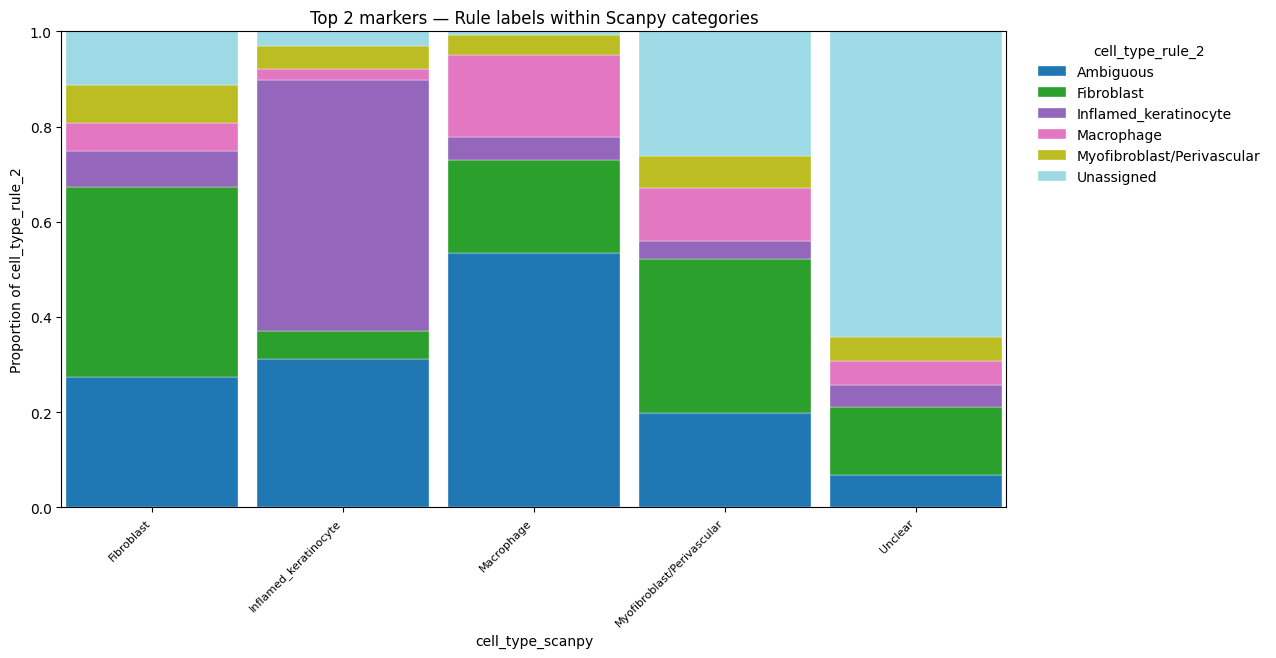


TOP 3 MARKERS


cell_type_rule_3
Fibroblast                    16472
Unassigned                    16207
Inflamed_keratinocyte         15532
Ambiguous                     13033
Myofibroblast/Perivascular     5299
Macrophage                     4595
Name: count, dtype: int64

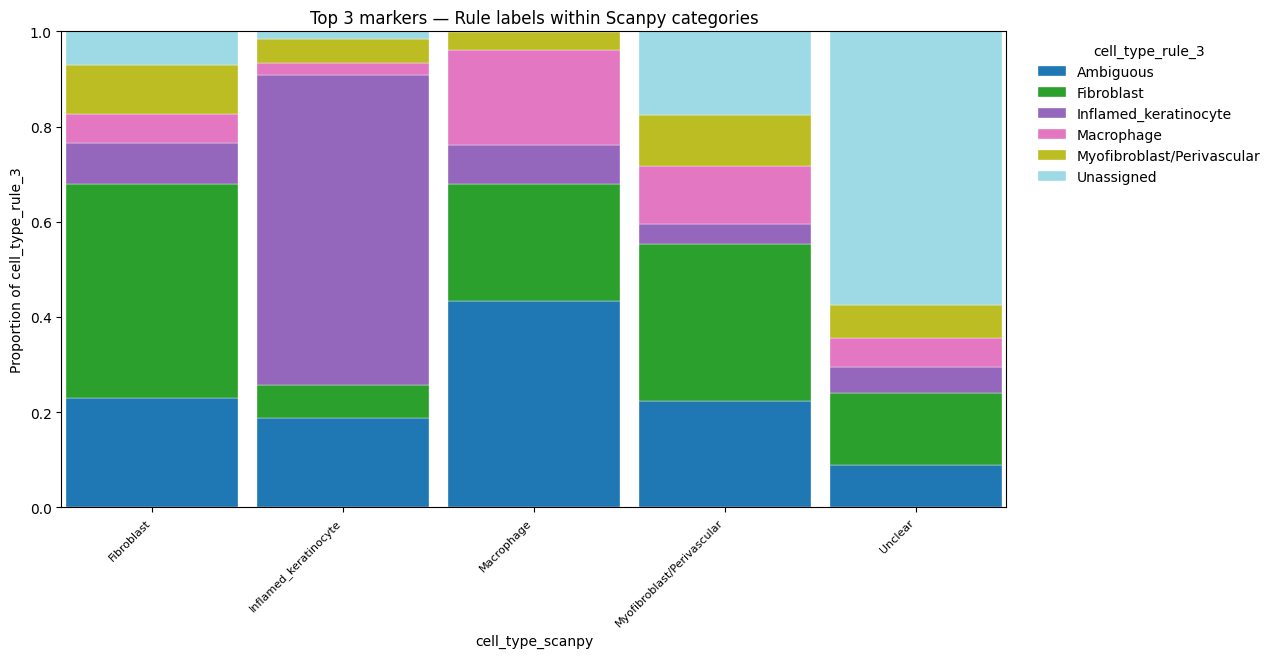


TOP 4 MARKERS


cell_type_rule_4
Fibroblast                    17991
Inflamed_keratinocyte         16482
Unassigned                    14561
Ambiguous                     11550
Macrophage                     5557
Myofibroblast/Perivascular     4997
Name: count, dtype: int64

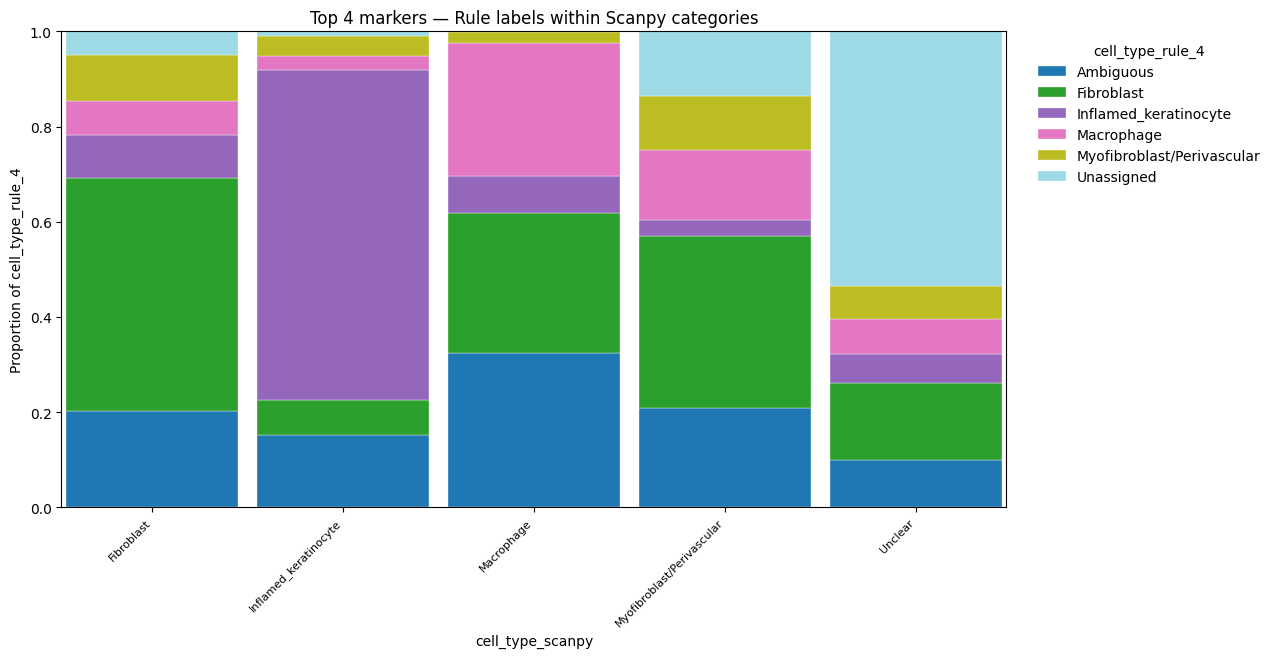

In [92]:
# Compare rule-based labels using 2, 3, and 4 markers

for n_markers in [2, 3, 4]:

    # Store the labels for this marker number
    adata.obs[f"cell_type_rule_{n_markers}"] = pd.Categorical(
        results[n_markers]
    )

    print("\n" + "=" * 70)
    print(f"TOP {n_markers} MARKERS")
    print("=" * 70)

    # Show cell counts
    display(
        adata.obs[f"cell_type_rule_{n_markers}"]
        .value_counts()
    )

    # Plot against Scanpy/reference labels
    custom_barplot(
        adata,
        var_1=f"cell_type_rule_{n_markers}",
        var_2="cell_type_scanpy",
        plot_type="bar",
        cluster_bars=False,
        title=f"Top {n_markers} markers — Rule labels within Scanpy categories",
    )


In [93]:
# Compare cell-type counts across 2, 3, and 4 markers

comparison = pd.DataFrame({
    f"Top {n}": pd.Series(results[n]).value_counts()
    for n in [2, 3, 4]
}).fillna(0).astype(int)

display(comparison)


,Top 2,Top 3,Top 4
Ambiguous,15983,13033,11550
Fibroblast,14819,16472,17991
Inflamed_keratinocyte,12725,15532,16482
Macrophage,4019,4595,5557
Myofibroblast/Perivascular,4216,5299,4997
Unassigned,19376,16207,14561


In [94]:
for n_markers in [2, 3, 4]:

    table = pd.crosstab(
        adata.obs["cell_type_scanpy"],
        adata.obs[f"cell_type_rule_{n_markers}"],
        normalize="index"
    ).round(3)

    print(f"\nTop {n_markers} markers")
    display(table)


Top 2 markers


cell_type_rule_2,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.274,0.399,0.075,0.060,0.079,0.113
Inflamed_keratinocyte,0.312,0.057,0.529,0.022,0.048,0.032
Macrophage,0.534,0.196,0.047,0.172,0.044,0.007
Myofibroblast/Perivascular,0.198,0.324,0.038,0.110,0.067,0.262
Unclear,0.069,0.141,0.046,0.050,0.052,0.641



Top 3 markers


cell_type_rule_3,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.230,0.449,0.086,0.062,0.104,0.070
Inflamed_keratinocyte,0.188,0.068,0.651,0.027,0.049,0.017
Macrophage,0.433,0.247,0.082,0.200,0.037,0.002
Myofibroblast/Perivascular,0.223,0.330,0.041,0.123,0.106,0.176
Unclear,0.090,0.150,0.054,0.062,0.070,0.574



Top 4 markers


cell_type_rule_4,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,0.202,0.490,0.089,0.071,0.097,0.050
Inflamed_keratinocyte,0.152,0.073,0.693,0.030,0.042,0.010
Macrophage,0.325,0.293,0.078,0.278,0.024,0.001
Myofibroblast/Perivascular,0.210,0.361,0.034,0.146,0.115,0.135
Unclear,0.100,0.161,0.061,0.075,0.067,0.536


In [95]:
for n_markers in [2, 3, 4]:

    table = pd.crosstab(
        adata.obs["cell_type_scanpy"],
        adata.obs[f"cell_type_rule_{n_markers}"]
    )

    print(f"\nTop {n_markers} markers")
    display(table)



Top 2 markers


cell_type_rule_2,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,5551,8097,1526,1213,1612,2283
Inflamed_keratinocyte,5752,1056,9735,409,877,583
Macrophage,2092,768,185,672,171,26
Myofibroblast/Perivascular,949,1552,184,529,323,1258
Unclear,1639,3346,1095,1196,1233,15226



Top 3 markers


cell_type_rule_3,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,4669,9113,1735,1251,2102,1412
Inflamed_keratinocyte,3462,1257,11994,493,893,313
Macrophage,1693,965,320,783,144,9
Myofibroblast/Perivascular,1071,1584,195,592,510,843
Unclear,2138,3553,1288,1476,1650,13630



Top 4 markers


cell_type_rule_4,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,4103,9943,1813,1441,1975,1007
Inflamed_keratinocyte,2805,1345,12759,544,777,182
Macrophage,1273,1148,306,1088,94,5
Myofibroblast/Perivascular,1005,1729,162,701,551,647
Unclear,2364,3826,1442,1783,1600,12720


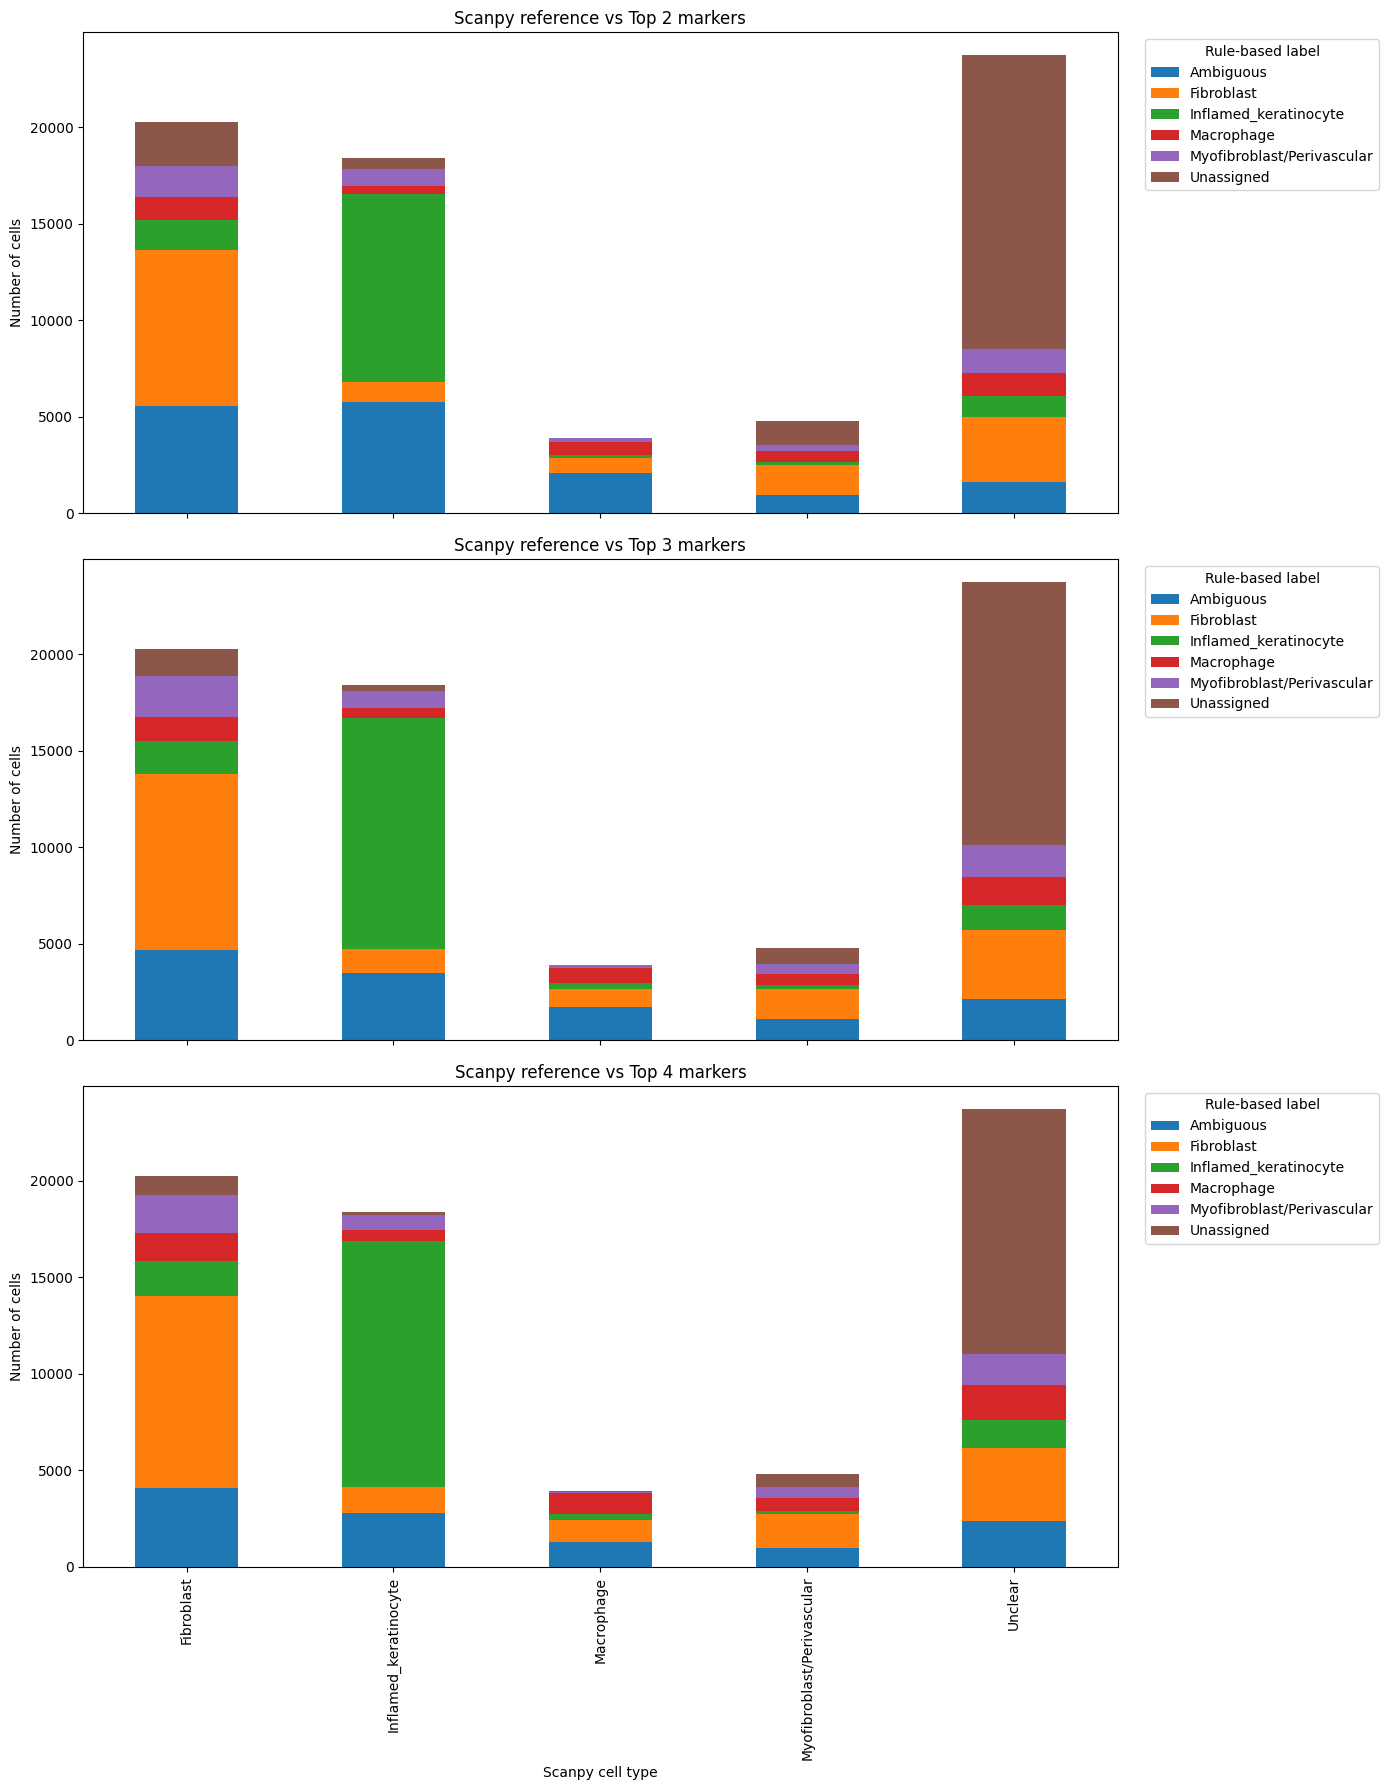

In [96]:
plot_df = pd.DataFrame({
    "Scanpy": adata.obs["cell_type_scanpy"].astype(str),
    "Top 2 markers": adata.obs["cell_type_rule_2"].astype(str),
    "Top 3 markers": adata.obs["cell_type_rule_3"].astype(str),
    "Top 4 markers": adata.obs["cell_type_rule_4"].astype(str),
})

long_df = pd.concat(
    [
        plot_df[["Scanpy", "Top 2 markers"]]
        .rename(columns={"Top 2 markers": "Assigned"})
        .assign(Method="Top 2 markers"),

        plot_df[["Scanpy", "Top 3 markers"]]
        .rename(columns={"Top 3 markers": "Assigned"})
        .assign(Method="Top 3 markers"),

        plot_df[["Scanpy", "Top 4 markers"]]
        .rename(columns={"Top 4 markers": "Assigned"})
        .assign(Method="Top 4 markers"),
    ],
    ignore_index=True
)

summary = (
    long_df
    .groupby(
        ["Method", "Scanpy", "Assigned"],
        observed=True
    )
    .size()
    .reset_index(name="Count")
)

methods = [
    "Top 2 markers",
    "Top 3 markers",
    "Top 4 markers",
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 18),
    sharex=True
)

for ax, method in zip(axes, methods):

    subset = summary[
        summary["Method"] == method
    ]

    pivot = (
        subset
        .pivot(
            index="Scanpy",
            columns="Assigned",
            values="Count"
        )
        .fillna(0)
    )

    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    ax.set_title(
        f"Scanpy reference vs {method}"
    )

    ax.set_ylabel("Number of cells")
    ax.set_xlabel("Scanpy cell type")

    ax.legend(
        title="Rule-based label",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

plt.tight_layout()
plt.show()


In [97]:
for n_markers in [2, 3, 4]:

    table = pd.crosstab(
        adata.obs["cell_type_scanpy"],
        adata.obs[f"cell_type_rule_{n_markers}"],
        normalize="index"
    ) * 100

    table = table.round(1)

    print(f"\nTop {n_markers} markers")
    display(table)



Top 2 markers


cell_type_rule_2,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,27.4,39.9,7.5,6.0,7.9,11.3
Inflamed_keratinocyte,31.2,5.7,52.9,2.2,4.8,3.2
Macrophage,53.4,19.6,4.7,17.2,4.4,0.7
Myofibroblast/Perivascular,19.8,32.4,3.8,11.0,6.7,26.2
Unclear,6.9,14.1,4.6,5.0,5.2,64.1



Top 3 markers


cell_type_rule_3,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,23.0,44.9,8.6,6.2,10.4,7.0
Inflamed_keratinocyte,18.8,6.8,65.1,2.7,4.9,1.7
Macrophage,43.3,24.7,8.2,20.0,3.7,0.2
Myofibroblast/Perivascular,22.3,33.0,4.1,12.3,10.6,17.6
Unclear,9.0,15.0,5.4,6.2,7.0,57.4



Top 4 markers


cell_type_rule_4,Ambiguous,Fibroblast,Inflamed_keratinocyte,Macrophage,Myofibroblast/Perivascular,Unassigned
cell_type_scanpy,,,,,,
Fibroblast,20.2,49.0,8.9,7.1,9.7,5.0
Inflamed_keratinocyte,15.2,7.3,69.3,3.0,4.2,1.0
Macrophage,32.5,29.3,7.8,27.8,2.4,0.1
Myofibroblast/Perivascular,21.0,36.1,3.4,14.6,11.5,13.5
Unclear,10.0,16.1,6.1,7.5,6.7,53.6


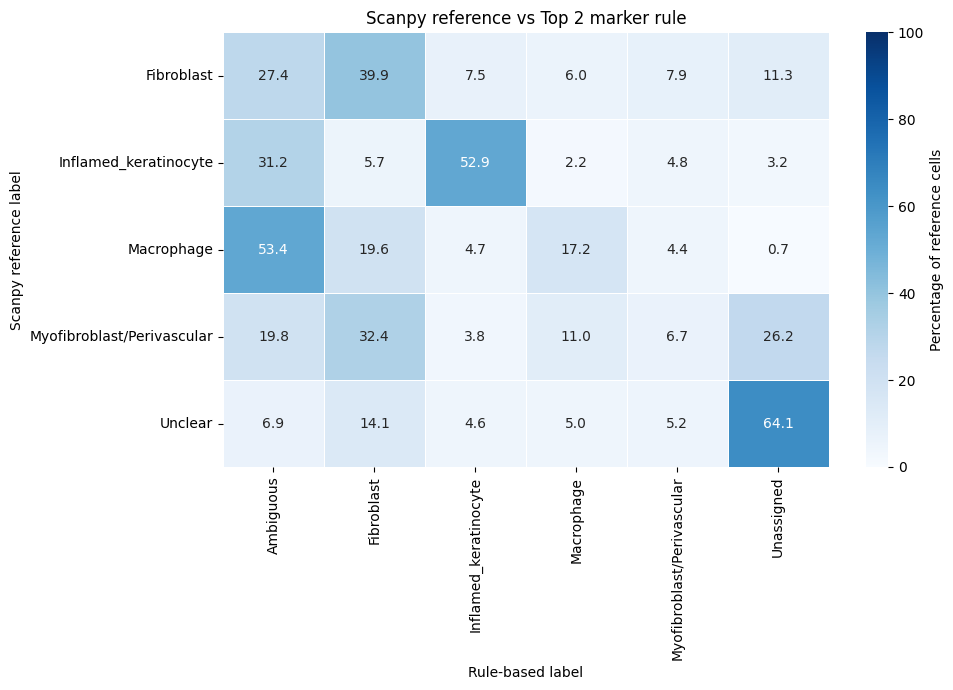

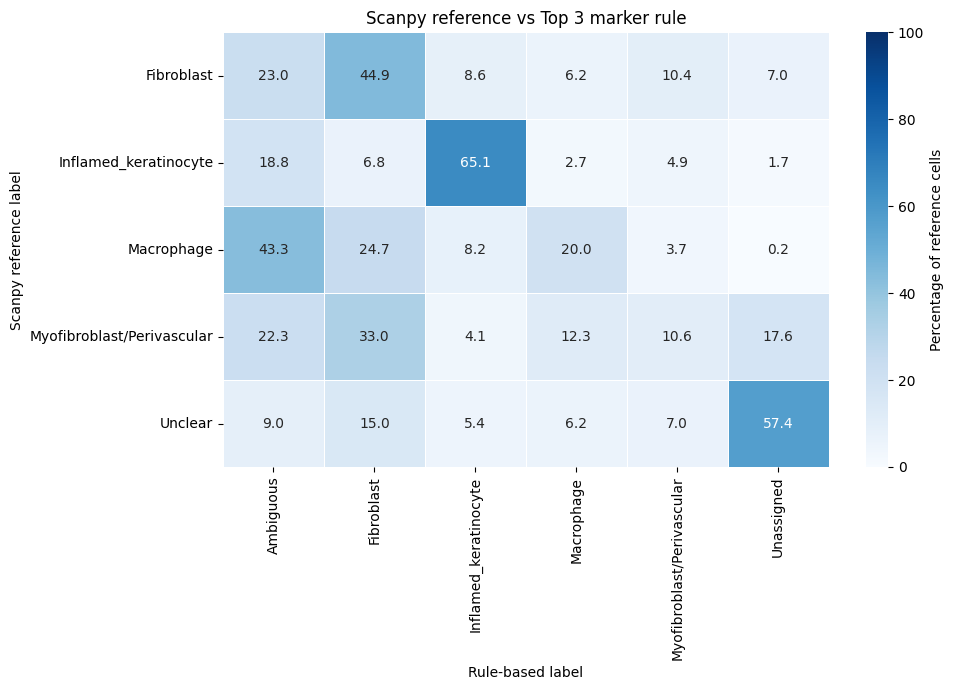

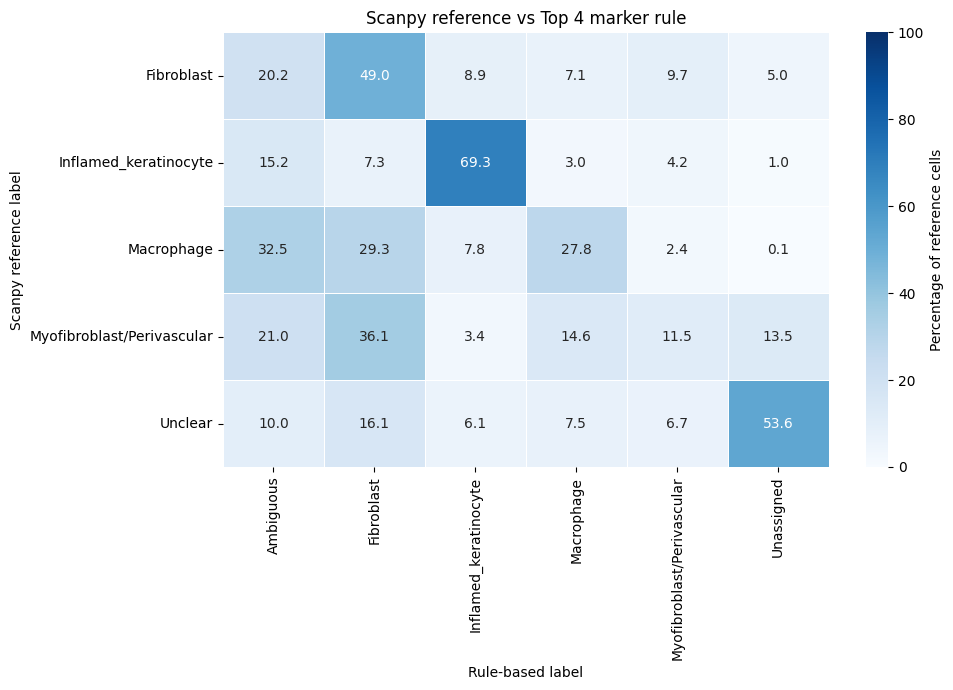

In [101]:
for n_markers in [2, 3, 4]:

    table = pd.crosstab(
        adata.obs["cell_type_scanpy"],
        adata.obs[f"cell_type_rule_{n_markers}"],
        normalize="index"
    ) * 100

    table = table.round(1)

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        table,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        cbar_kws={"label": "Percentage of reference cells"}
    )

    plt.title(
        f"Scanpy reference vs Top {n_markers} marker rule"
    )

    plt.xlabel("Rule-based label")
    plt.ylabel("Scanpy reference label")

    plt.tight_layout()
    plt.show()

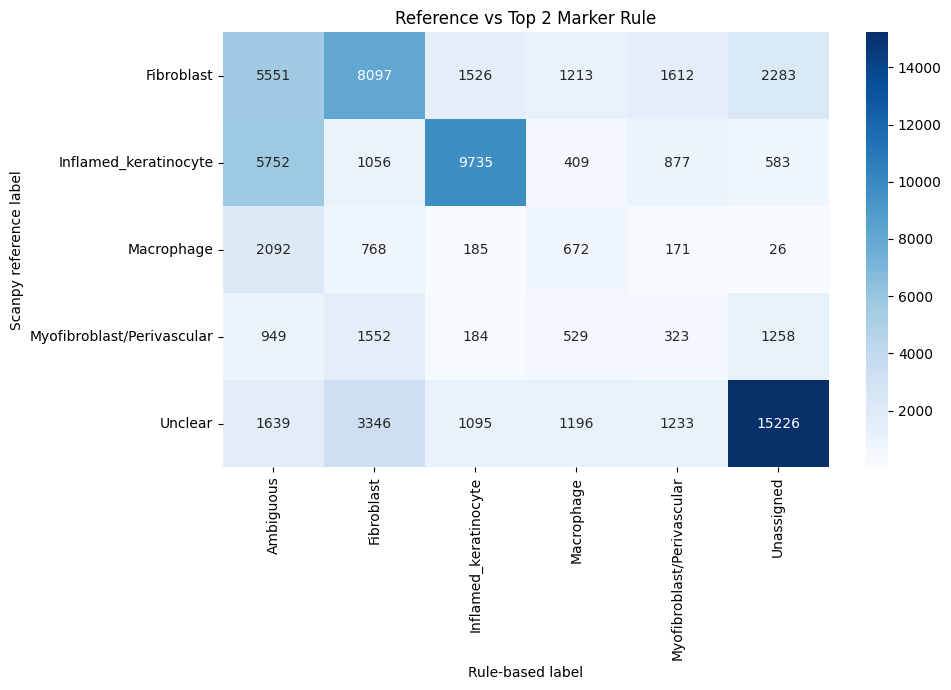

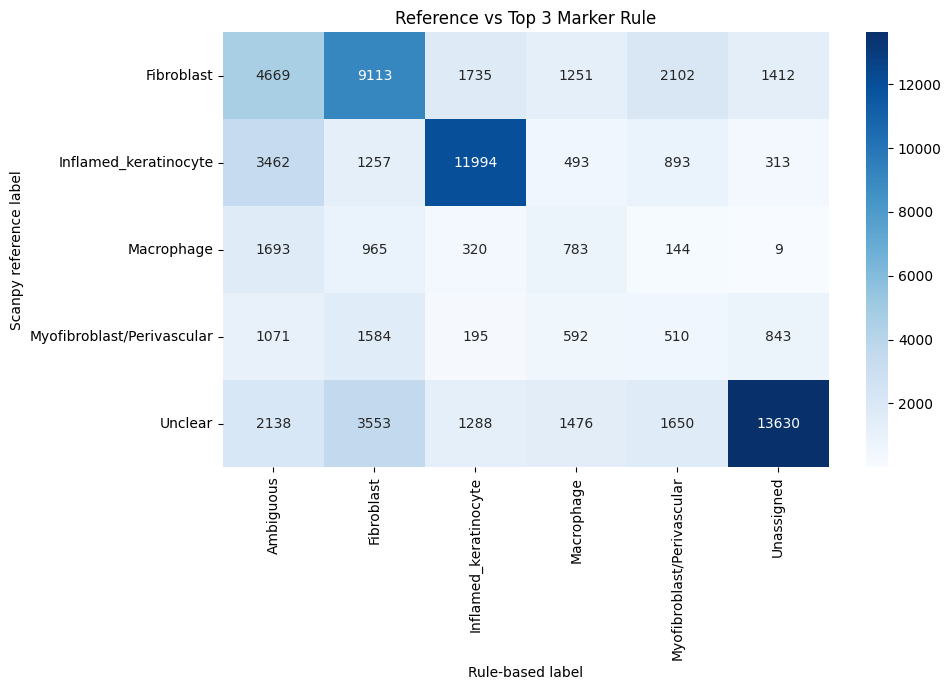

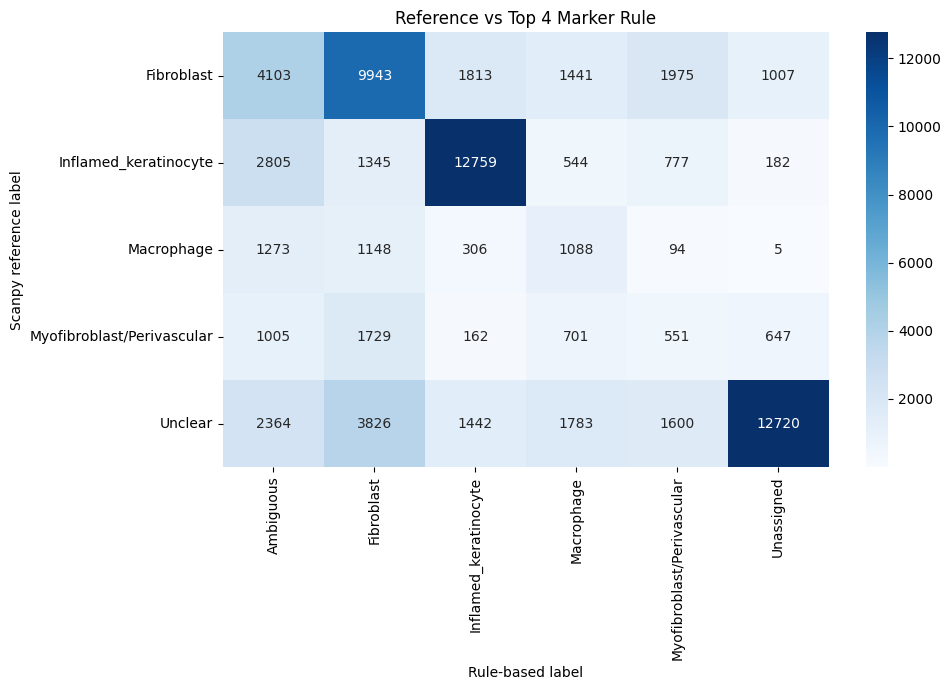

In [98]:
for n_markers in [2, 3, 4]:

    cm = pd.crosstab(
        adata.obs["cell_type_scanpy"],
        adata.obs[f"cell_type_rule_{n_markers}"]
    )

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Reference vs Top {n_markers} Marker Rule"
    )

    plt.xlabel("Rule-based label")
    plt.ylabel("Scanpy reference label")

    plt.tight_layout()
    plt.show()

In [99]:
for n_markers in [2, 3, 4]:

    y_true = adata.obs["cell_type_scanpy"].astype(str)
    y_pred = adata.obs[f"cell_type_rule_{n_markers}"].astype(str)

    cell_types = [
        "Fibroblast",
        "Inflamed_keratinocyte",
        "Myofibroblast/Perivascular",
        "Macrophage",
    ]

    metrics = []

    for cell_type in cell_types:

        true_positive = (
            (y_true == cell_type) &
            (y_pred == cell_type)
        ).sum()

        false_positive = (
            (y_true != cell_type) &
            (y_pred == cell_type)
        ).sum()

        false_negative = (
            (y_true == cell_type) &
            (y_pred != cell_type)
        ).sum()

        true_negative = (
            (y_true != cell_type) &
            (y_pred != cell_type)
        ).sum()

        metrics.append({
            "Cell type": cell_type,
            "TP": true_positive,
            "FP": false_positive,
            "FN": false_negative,
            "TN": true_negative,
        })

    metrics_df = pd.DataFrame(metrics)

    print(f"\nTop {n_markers} markers")
    display(metrics_df)


Top 2 markers


,Cell type,TP,FP,FN,TN
0,Fibroblast,8097,6722,12185,44134
1,Inflamed_keratinocyte,9735,2990,8677,49736
2,Myofibroblast/Perivascular,323,3893,4472,62450
3,Macrophage,672,3347,3242,63877



Top 3 markers


,Cell type,TP,FP,FN,TN
0,Fibroblast,9113,7359,11169,43497
1,Inflamed_keratinocyte,11994,3538,6418,49188
2,Myofibroblast/Perivascular,510,4789,4285,61554
3,Macrophage,783,3812,3131,63412



Top 4 markers


,Cell type,TP,FP,FN,TN
0,Fibroblast,9943,8048,10339,42808
1,Inflamed_keratinocyte,12759,3723,5653,49003
2,Myofibroblast/Perivascular,551,4446,4244,61897
3,Macrophage,1088,4469,2826,62755


Scanpy is useful for discovering cellular structure, while rule-based annotation provides transparent cell-level interpretation; combining both with explicit ambiguous/unassigned states provides a practical workflow for imaging-based spatial transcriptomics.